**Products**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [ ]:
file_path = Path.cwd().parent.parent/"Excel"/"1_Products.xlsx"
df = pd.read_excel(file_path)
df

,Product_ID,Product_Name,Category,Sub_Category,Unit_Cost,Selling_Price,Supplier_ID
0,P1000,Product 1,Office,Stationery,344.99,701.83,S131
1,P1001,Product 2,Beauty,Makeup,266.87,460.73,S108
2,P1002,Product 3,Toys,Plush,194.66,268.68,S139
3,P1003,Product 4,Fashion,Footwear,149.63,177.36,S119
4,P1004,NaN,Office,Office Supplies,210.06,288.91,S189
...,...,...,...,...,...,...,...
997,P1997,Product 998,Toys,Action Toys,111.23,133.17,S141
998,P1998,Product 999,Home & Kitchen,Appliances,188.99,242.41,S126
999,,Product 1000,Automotive,Cleaning,142.69,0.00,S110
1000,P1778,Product 779,Sports,Sportswear,232.12,478.65,S109


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     997 non-null    object 
 1   Product_Name   996 non-null    object 
 2   Category       995 non-null    object 
 3   Sub_Category   996 non-null    object 
 4   Unit_Cost      997 non-null    float64
 5   Selling_Price  997 non-null    float64
 6   Supplier_ID    993 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.9+ KB


In [4]:
# Capitalize, Trimming and Consistent null values
columns = [
    "Product_ID", "Product_Name", "Category", "Sub_Category", "Supplier_ID"
]
for col in columns:
    df[col] = df[col].str.capitalize()
    df[col] = df[col].str.strip()
nulls = ["N/a", "Na", "Null", "Unknown", ""]
df.replace(nulls, np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     990 non-null    object 
 1   Product_Name   991 non-null    object 
 2   Category       988 non-null    object 
 3   Sub_Category   993 non-null    object 
 4   Unit_Cost      997 non-null    float64
 5   Selling_Price  997 non-null    float64
 6   Supplier_ID    984 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.9+ KB


In [5]:
# Dropping duplicates except nulls
mask = df["Product_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Product_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)
df.head()

,Product_ID,Product_Name,Category,Sub_Category,Unit_Cost,Selling_Price,Supplier_ID
0,P1000,Product 1,Office,Stationery,344.99,701.83,S131
1,P1001,Product 2,Beauty,Makeup,266.87,460.73,S108
2,P1002,Product 3,Toys,Plush,194.66,268.68,S139
3,P1003,Product 4,Fashion,Footwear,149.63,177.36,S119
4,P1004,NaN,Office,Office supplies,210.06,288.91,S189


In [6]:
# Replacing null values in Product ID
for i in range(len(df)):
    value = df.loc[i, "Product_ID"]
    if not pd.notna(value):
        df.loc[i, "Product_ID"] = f"P{1000+i}"
df["Product_ID"].isna().sum()
df["Product_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   989 non-null    object 
 2   Category       986 non-null    object 
 3   Sub_Category   991 non-null    object 
 4   Unit_Cost      995 non-null    float64
 5   Selling_Price  995 non-null    float64
 6   Supplier_ID    982 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [7]:
# Replacing null values in Product Name
df["Product_Name"].isna().sum()
df["Product_Name"].head()
mask = df["Product_Name"].isna()
for i in range(len(df)):
    value = df.loc[i, "Product_Name"]
    if not pd.notna(value):
        df.loc[i, "Product_Name"] = f"Product {i+1}"
df["Product_Name"].isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   1000 non-null   object 
 2   Category       986 non-null    object 
 3   Sub_Category   991 non-null    object 
 4   Unit_Cost      995 non-null    float64
 5   Selling_Price  995 non-null    float64
 6   Supplier_ID    982 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [8]:
# Mapping Categories with Sub Categories
df["Category"].isna().sum()
mapping = (
  df.dropna(subset=["Category"])
  .drop_duplicates(subset=["Sub_Category"])
  .set_index("Sub_Category")["Category"]
  .to_dict()
)
df["Category"] = df["Category"].fillna(df["Sub_Category"].map(mapping))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Sub_Category   991 non-null    object 
 4   Unit_Cost      995 non-null    float64
 5   Selling_Price  995 non-null    float64
 6   Supplier_ID    982 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [9]:
# Mapping Sub Categories with previous Categories
df[df["Sub_Category"].isna()]
mapping = (
  df.dropna(subset=["Sub_Category"])
    .drop_duplicates(subset=["Category"])
    .set_index("Category")["Sub_Category"]
    .to_dict()
)
df["Sub_Category"] = df["Sub_Category"].fillna(df["Category"].map(mapping))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Sub_Category   1000 non-null   object 
 4   Unit_Cost      995 non-null    float64
 5   Selling_Price  995 non-null    float64
 6   Supplier_ID    982 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [10]:
# Checking inconsistencies in Unit Cost
df["Unit_Cost"].isna().sum()
(df["Unit_Cost"]<0).sum()

np.int64(5)

In [11]:
purchases_path = Path.cwd().parent.parent/"Excel"/"7_Purchases.xlsx"
purchases_df = pd.read_excel(purchases_path)
purchases_df

,Purchase_ID,Supplier_ID,Product_ID,Warehouse_ID,Purchase_Date,Quantity,Unit_Cost,Expected_Date,Actual_Date
0,PUR1000000,S105,P1063,W107,2025-05-01,691.0,514.16,2025-05-12,2025-05-17
1,PUR1000001,S184,P1355,W107,2025-01-23,1946.0,349.72,2025-01-25,2025-02-06
2,PUR1000002,S155,P1180,W114,2025-06-05,658.0,206.50,2025-07-04,2025-07-04
3,PUR1000003,S101,P1598,W116,2025-06-11,80.0,108.78,2025-07-08,2025-07-10
4,PUR1000004,S121,P1083,W112,2025-07-18,1082.0,121.36,2025-08-08,2025-08-06
...,...,...,...,...,...,...,...,...,...
75145,PUR1040422,S196,P1742,W114,2025-10-09,2684.0,171.29,2025-10-29,2025-10-31
75146,PUR1046443,S113,P1452,W101,2025-11-07,1546.0,130.48,2025-11-18,2025-11-19
75147,PUR1026155,S156,P1590,W114,2025-01-02,2768.0,85.25,2025-02-01,2025-02-01
75148,PUR1010759,S193,P1706,W105,2025-12-06,942.0,135.20,2025-12-15,2025-12-16


In [12]:
# Mapping Product ID and Unit Cost from Purchases Data
purchases_df["Product_ID"] = purchases_df["Product_ID"].str.upper()
mapping = (
    purchases_df.dropna(subset=["Unit_Cost"])
    .drop_duplicates(subset=["Product_ID"])
    .set_index("Product_ID")["Unit_Cost"]
    .to_dict()
)
df["Unit_Cost"] = df["Unit_Cost"].fillna(df["Product_ID"].map(mapping))
df.loc[df["Unit_Cost"]<=0, "Unit_Cost"] = df["Product_ID"].map(mapping)
df["Unit_Cost"].isna().sum()

np.int64(0)

In [13]:
# Correction of nulls and negatives in Selling Price
df["Selling_Price"].isna().sum()
(df["Selling_Price"]<0).sum()
df.loc[df["Selling_Price"]<0, "Selling_Price"] *= -1
mean_price_diff = (df["Selling_Price"]-df["Unit_Cost"]).mean()
new_selling_price = (df["Unit_Cost"]+mean_price_diff).round(2)
df["Selling_Price"] = df["Selling_Price"].fillna(new_selling_price)
df.loc[df["Selling_Price"]==0, "Selling_Price"] = new_selling_price

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Sub_Category   1000 non-null   object 
 4   Unit_Cost      1000 non-null   float64
 5   Selling_Price  1000 non-null   float64
 6   Supplier_ID    982 non-null    object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [15]:
# Mapping Product ID with Supplier ID from Purchases Data
df["Supplier_ID"].isna().sum()
purchases_df["Supplier_ID"] = purchases_df["Supplier_ID"].str.upper()
mapping = (
  purchases_df.dropna(subset=["Supplier_ID"])
  .drop_duplicates(subset=["Product_ID"])
  .set_index("Product_ID")["Supplier_ID"]
  .to_dict()
)
df["Supplier_ID"] = df["Supplier_ID"].fillna(df["Product_ID"].map(mapping))
df["Supplier_ID"].isna().sum()

np.int64(0)

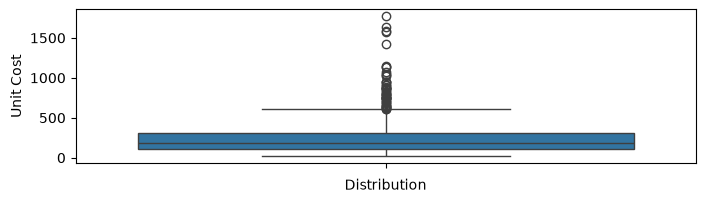

count    1000.000000
mean      241.847280
std       205.612656
min        16.910000
25%       112.352500
50%       184.535000
75%       310.552500
max      1769.150000
Name: Unit_Cost, dtype: float64

In [16]:
plt.figure(figsize=(8,2))
sb.boxplot(df["Unit_Cost"])
plt.xlabel("Distribution")
plt.ylabel("Unit Cost")
plt.show()
df["Unit_Cost"].describe()

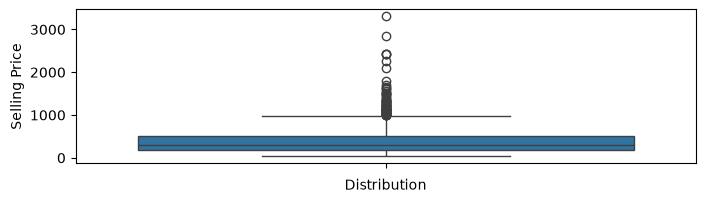

count    1000.000000
mean      407.685450
std       346.694759
min        33.480000
25%       185.447500
50%       309.920000
75%       505.127500
max      3305.160000
Name: Selling_Price, dtype: float64

In [17]:
plt.figure(figsize=(8,2))
sb.boxplot(df["Selling_Price"])
plt.xlabel("Distribution")
plt.ylabel("Selling Price")
plt.show()
df["Selling_Price"].describe()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     1000 non-null   object 
 1   Product_Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Sub_Category   1000 non-null   object 
 4   Unit_Cost      1000 non-null   float64
 5   Selling_Price  1000 non-null   float64
 6   Supplier_ID    1000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB


In [19]:
df.to_csv("../../Data/Cleaned/Products.csv", index=False)